In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt



In [2]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split



In [3]:
import os
import random

os.environ["PYTHONHASHSEED"] = "0"
os.environ.setdefault("TF_DETERMINISTIC_OPS", "1")

random.seed(0)
np.random.seed(0)

# FIX: tf_keras import triggers a protobuf MessageFactory.GetPrototype crash in this runtime.
# Use the installed Keras 3 API instead; core model/training logic stays the same.
import keras
from keras.models import Sequential
from keras.layers import Dense, Dropout
from keras.utils import to_categorical

try:
    keras.utils.set_random_seed(0)
except Exception:
    pass



2026-01-16 19:49:27.676492: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1768592967.689514      11 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1768592967.693431      11 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-01-16 19:49:27.708917: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

In [4]:
from pylab import rcParams

rcParams["figure.figsize"] = 10, 10



In [5]:
import os

TRAIN_PATHS = [
    "../input/train.csv",
    "/kaggle/input/train.csv",
    "/kaggle/input/leaf-classification/train.csv",
    "/kaggle/data/train.csv",
    "/kaggle/data/leaf-classification/train.csv",
]
train_path = next((p for p in TRAIN_PATHS if os.path.exists(p)), None)
if train_path is None:
    raise FileNotFoundError("Could not find train.csv in expected Kaggle locations.")

data = pd.read_csv(train_path)
parent_data = data.copy()  # Always a good idea to keep a copy of original data
ID = data.pop("id")



In [6]:
data.shape



(891, 193)

In [7]:
y = data.pop("species")
le = LabelEncoder()
y = le.fit_transform(y)
print(y.shape)



(891,)


In [8]:
scaler = StandardScaler()
X = scaler.fit_transform(data.values)
print(X.shape)



(891, 192)


In [9]:
y_cat = to_categorical(y)
print(y_cat.shape)



(891, 99)


In [10]:
model = Sequential()
model.add(
    Dense(2048, input_dim=X.shape[1], kernel_initializer="uniform", activation="relu")
)
model.add(Dropout(0.3))
model.add(Dense(1024, activation="sigmoid"))
model.add(Dropout(0.3))
model.add(Dense(y_cat.shape[1], activation="softmax"))



/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-01-16 19:49:33.528582: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.
I0000 00:00:1768592973.529084      11 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 39797 MB memory:  -> device: 0, name: NVIDIA RTX A6000, pci bus id: 0000:c5:00.0, compute capability: 8.6


In [11]:
model.compile(
    loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.01),
    optimizer="rmsprop",
    metrics=["accuracy"],
)



In [12]:
history = model.fit(
    X, y_cat, batch_size=128, epochs=100, verbose=0, validation_split=0.1
)



2026-01-16 19:49:34.054639: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


In [13]:
val_acc_key = "val_accuracy" if "val_accuracy" in history.history else "val_acc"
print(min(history.history[val_acc_key]))



0.15555556118488312


Text(0.5, 1.0, 'Validation Accuracy vs Number of Iterations')

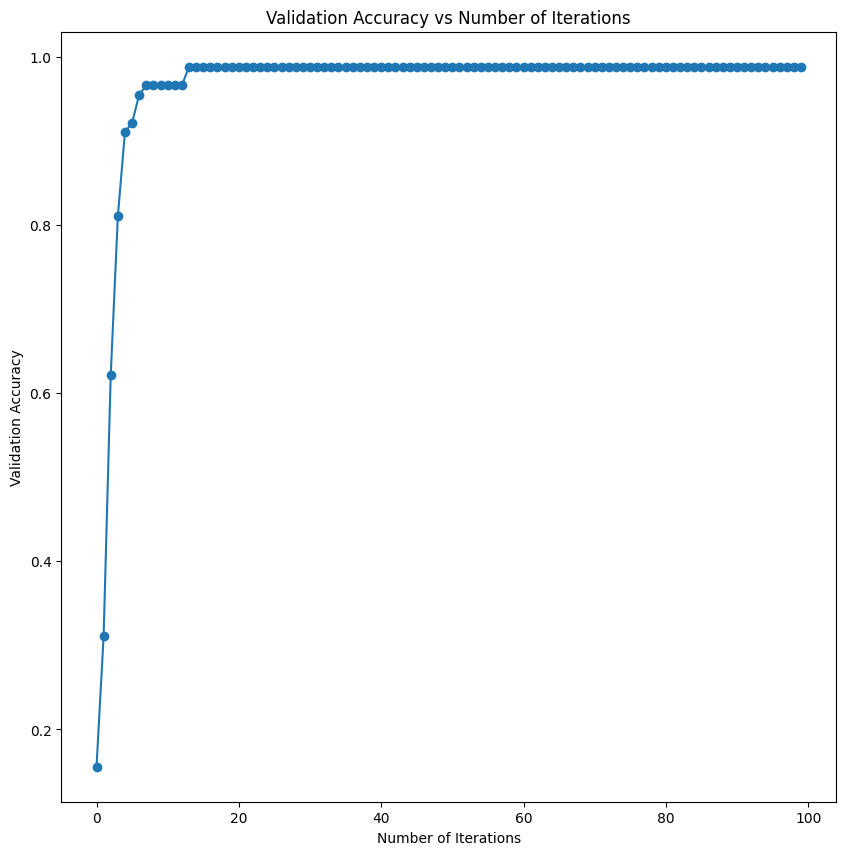

In [14]:
plt.plot(history.history[val_acc_key], "o-")
plt.xlabel("Number of Iterations")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy vs Number of Iterations")



In [15]:
TEST_PATHS = [
    "../input/test.csv",
    "/kaggle/input/test.csv",
    "/kaggle/input/leaf-classification/test.csv",
    "/kaggle/data/test.csv",
    "/kaggle/data/leaf-classification/test.csv",
]
test_path = next((p for p in TEST_PATHS if os.path.exists(p)), None)
if test_path is None:
    raise FileNotFoundError("Could not find test.csv in expected Kaggle locations.")

test = pd.read_csv(test_path)



In [16]:
index = test.pop("id")



In [17]:
test_scaled = scaler.transform(test.values)



In [18]:
yPred = model.predict(test_scaled, verbose=0)

eps = 1e-15
yPred = np.clip(yPred, eps, 1.0 - eps)

SUB_PATHS = [
    "../input/sample_submission.csv",
    "/kaggle/input/sample_submission.csv",
    "/kaggle/input/leaf-classification/sample_submission.csv",
    "/kaggle/data/sample_submission.csv",
    "/kaggle/data/leaf-classification/sample_submission.csv",
]
sub_path = next((p for p in SUB_PATHS if os.path.exists(p)), None)
if sub_path is None:
    raise FileNotFoundError(
        "Could not find sample_submission.csv in expected Kaggle locations."
    )

sample_sub = pd.read_csv(sub_path)
class_cols = [c for c in sample_sub.columns if c != "id"]

pred_df = pd.DataFrame(yPred, columns=le.classes_, index=index)
pred_df = pred_df.reindex(columns=class_cols, fill_value=eps)

submission = pred_df.copy()
submission.insert(0, "id", index.values)

submission_path = "submission_nn_kernel.csv"
submission.to_csv(submission_path, index=False)

print("Wrote submission to:", submission_path)
print(submission.head())

Wrote submission to: submission_nn_kernel.csv
        id  Acer_Capillipes  Acer_Circinatum  Acer_Mono  Acer_Opalus  \
id                                                                     
1202  1202         0.000121         0.000140   0.000544     0.000176   
992    992         0.002170         0.000452   0.000848     0.001167   
491    491         0.000477         0.000199   0.000366     0.000914   
1201  1201         0.000322         0.000183   0.000397     0.000469   
72      72         0.000122         0.000028   0.000134     0.000034   

      Acer_Palmatum  Acer_Pictum  Acer_Platanoids  Acer_Rubrum  \
id                                                               
1202       0.000186     0.000649         0.000057     0.000389   
992        0.000660     0.001070         0.000659     0.000199   
491        0.000545     0.000956         0.000271     0.000585   
1201       0.000108     0.000024         0.000080     0.000093   
72         0.000052     0.000403         0.000033    

2026-01-16 19:49:41.429408: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}
